✓ All libraries imported

1. LOADING GERMAN CREDIT DATASET
✓ German Credit loaded: (1000, 21)
  Default rate: 30.0%
  Class distribution: {0: 700, 1: 300}


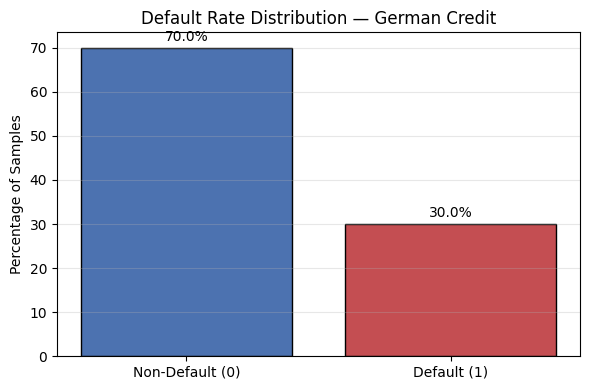


2. PREPROCESSING
  Categorical features: 13
  Numeric features: 7
  Processed features after OHE: 48

3. TUNING / EVALUATION SPLIT
  Tuning pool:    500 samples (stratified)
  Evaluation pool: 500 samples (stratified)
  Tuning default rate:    30.0%
  Evaluation default rate: 30.0%

4. HYPERPARAMETER OPTIMISATION (RandomizedSearchCV)

  === Tuning RF ===
Fitting 4 folds for each of 15 candidates, totalling 60 fits
  Best RF CV AUC: 0.7766
  Best params: {'clf__n_estimators': 120, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': None, 'clf__class_weight': 'balanced'}

  === Tuning XGB ===
Fitting 4 folds for each of 15 candidates, totalling 60 fits
  Best XGB CV AUC: 0.7678
  Best params: {'clf__subsample': 0.8, 'clf__scale_pos_weight': 5, 'clf__reg_lambda': 5, 'clf__n_estimators': 80, 'clf__max_depth': 8, 'clf__learning_rate': 0.008, 'clf__colsample_bytree': 0.6}

  === Tuning LGB ===
Fitting 4 folds for each of 15 candidates, to

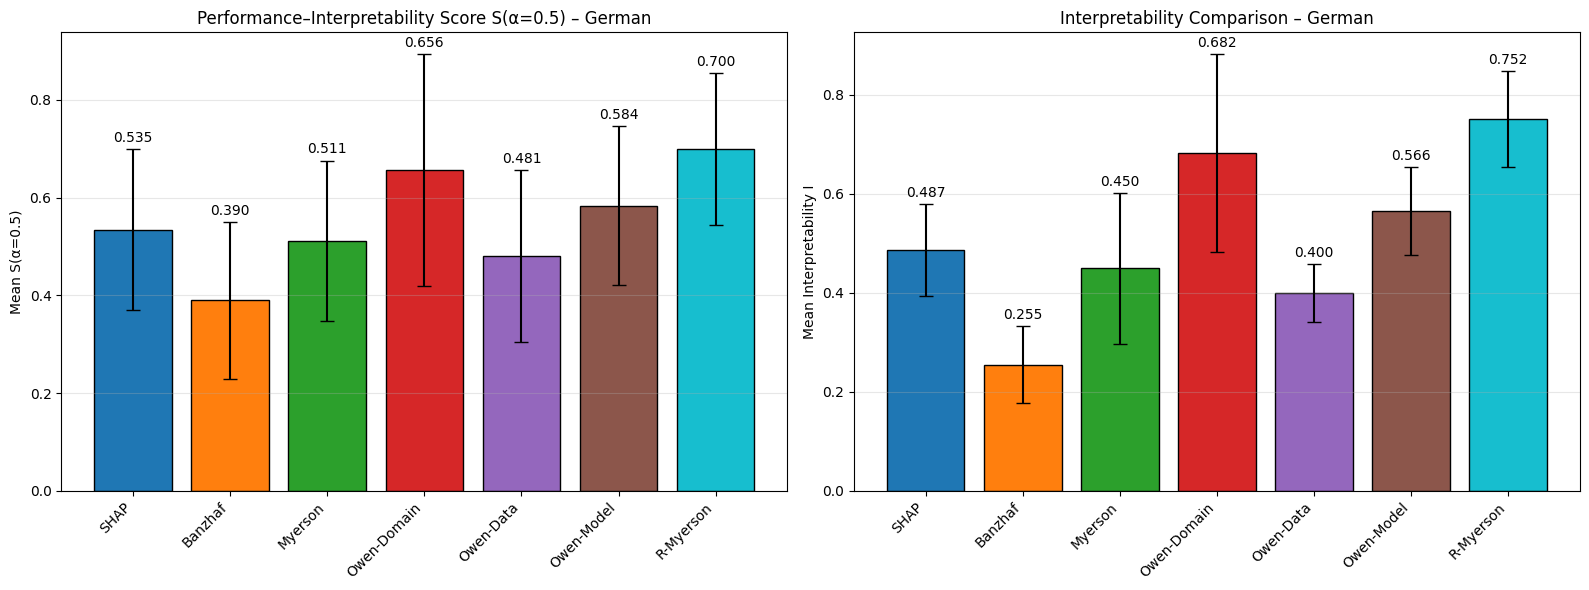

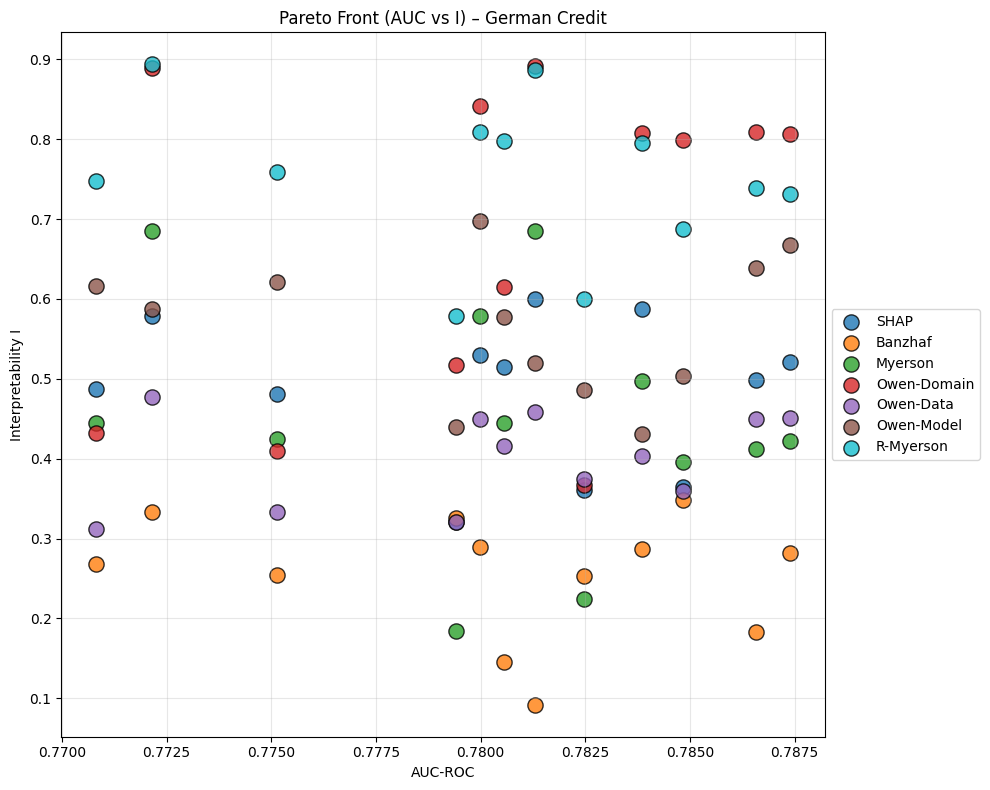

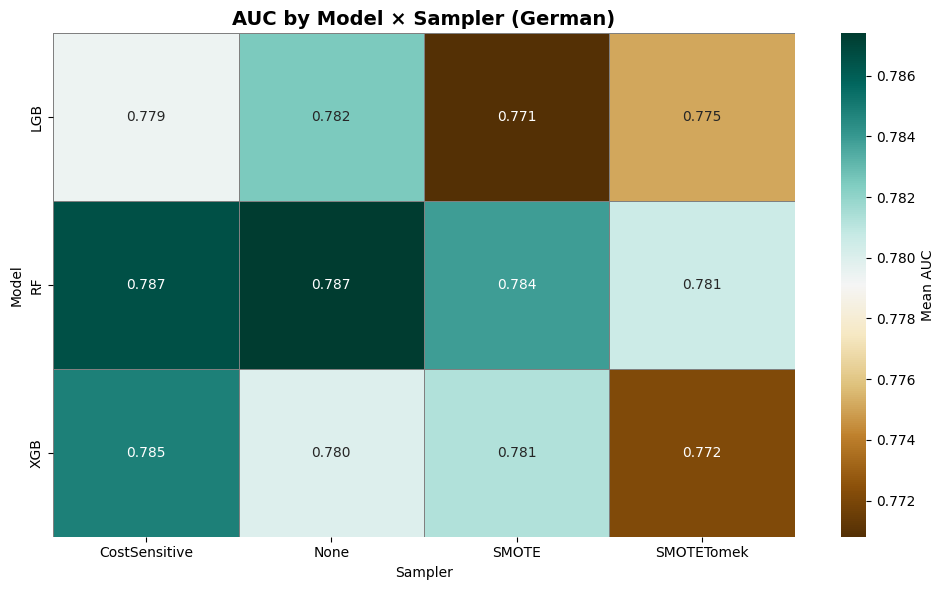

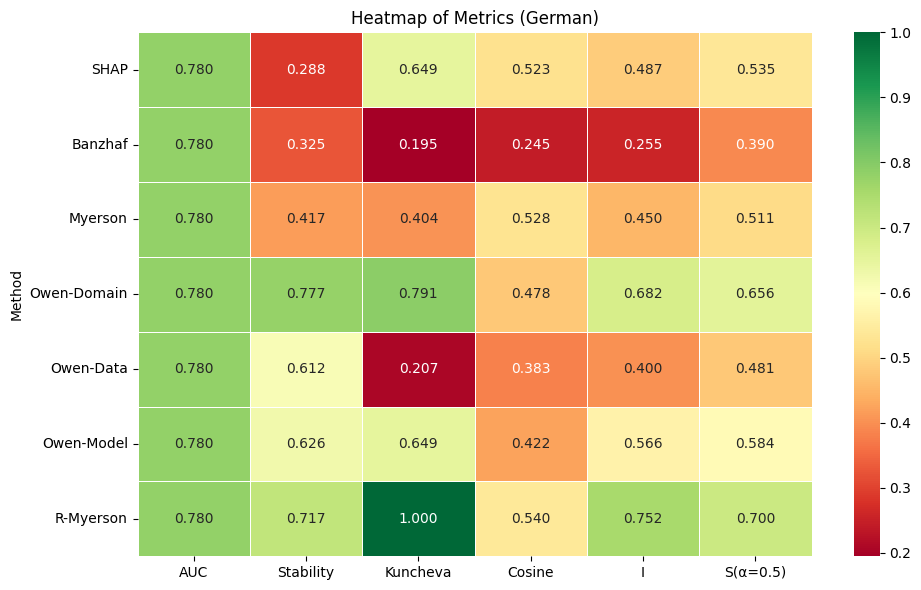

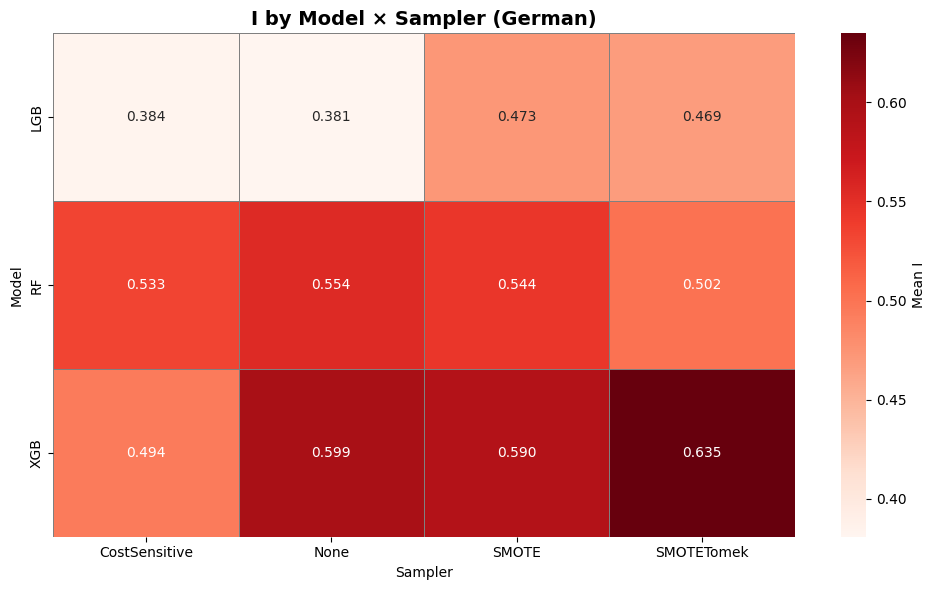

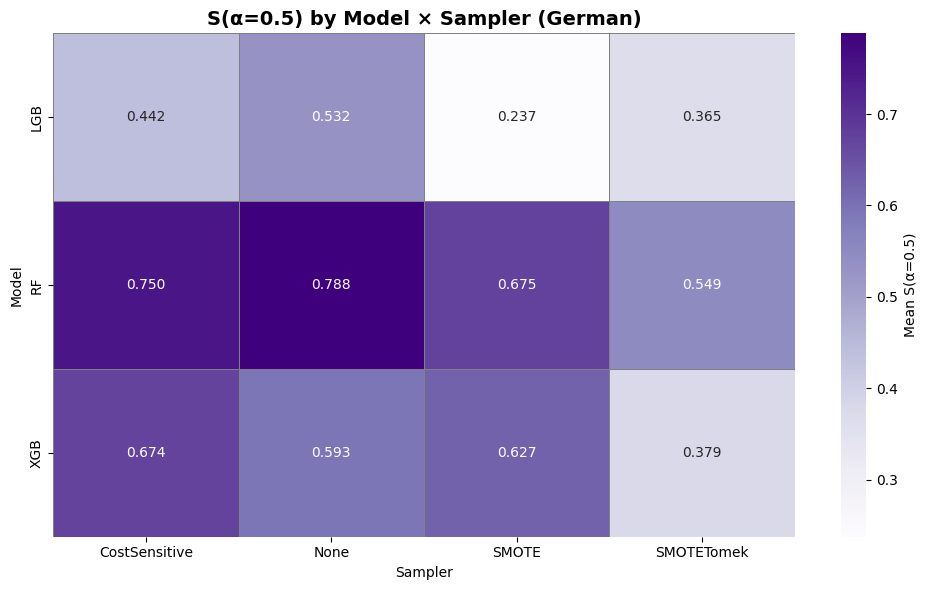

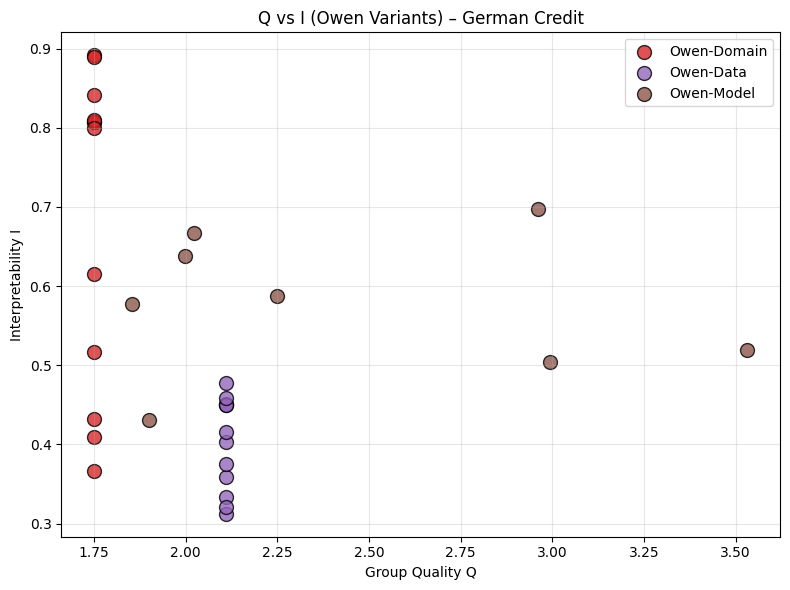

✓ All plots saved

13. GLOBAL & LOCAL AGREEMENT MATRICES


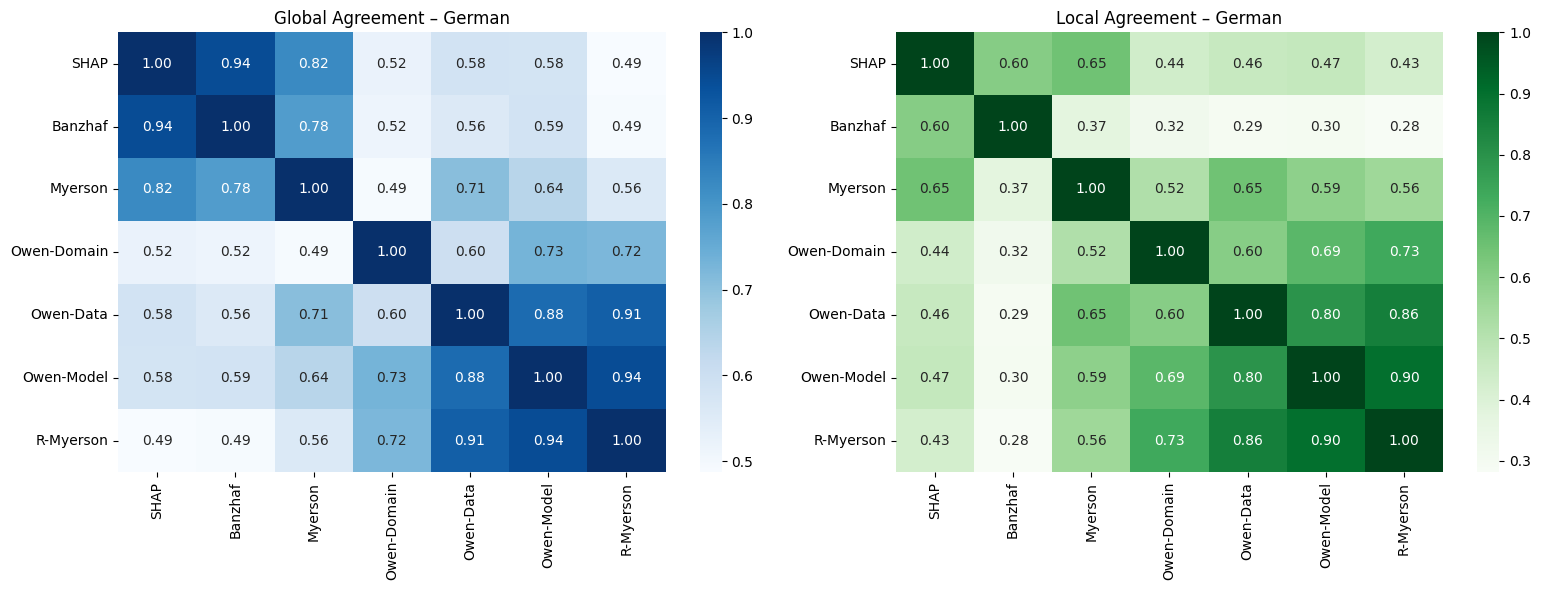


Global Agreement Matrix:
              SHAP  Banzhaf  Myerson  Owen-Domain  Owen-Data  Owen-Model  \
SHAP         1.000    0.944    0.824        0.523      0.584       0.580   
Banzhaf      0.944    1.000    0.784        0.515      0.558       0.585   
Myerson      0.824    0.784    1.000        0.493      0.707       0.639   
Owen-Domain  0.523    0.515    0.493        1.000      0.598       0.731   
Owen-Data    0.584    0.558    0.707        0.598      1.000       0.882   
Owen-Model   0.580    0.585    0.639        0.731      0.882       1.000   
R-Myerson    0.487    0.493    0.560        0.724      0.907       0.944   

             R-Myerson  
SHAP             0.487  
Banzhaf          0.493  
Myerson          0.560  
Owen-Domain      0.724  
Owen-Data        0.907  
Owen-Model       0.944  
R-Myerson        1.000  

Local Agreement Matrix:
              SHAP  Banzhaf  Myerson  Owen-Domain  Owen-Data  Owen-Model  \
SHAP         1.000    0.605    0.647        0.436      0.463    

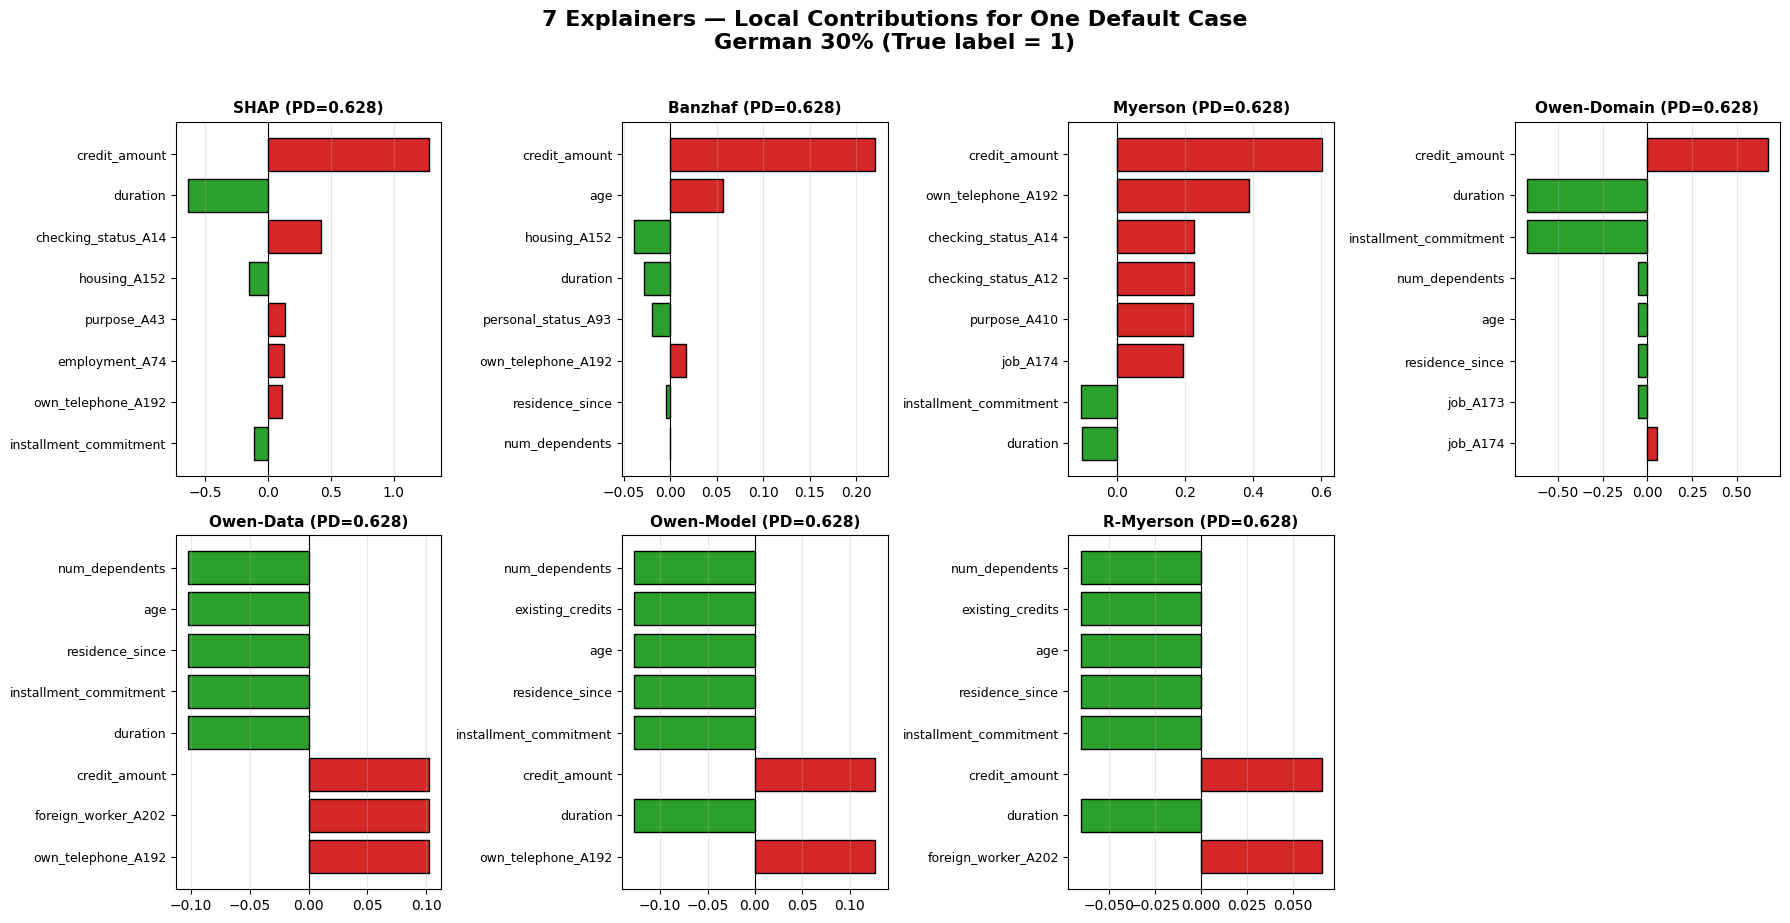


EXPERIMENT COMPLETE — German Credit Dataset

Output files:
  Ger_result.csv              — Main results (84 records: 3×4×7)
  Ger_result_nemenyi.csv      — Nemenyi post-hoc p-values
  Ger_result_wilcoxon.csv     — Wilcoxon + Cliff's delta
  Ger_result_correlation.csv  — AUC vs I correlation

Plots:
  Ger_default_distribution.png
  Ger_S_I_barplots.png
  Ger_pareto_front.png
  Ger_AUC_heatmap.png
  Ger_metrics_heatmap.png
  Ger_I_heatmap.png
  Ger_S_heatmap.png
  Ger_Q_vs_I.png
  Ger_agreement_matrices.png
  Ger_7explainers_local.png

Tuning AUCs (Table 2.2):
  RF:  0.7766
  XGB: 0.7678
  LGB: 0.7642



In [1]:
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 0. INSTALL & IMPORTS
# ============================================================
!pip install --quiet xgboost lightgbm imbalanced-learn shap networkx seaborn numba scikit_posthocs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    StratifiedKFold, train_test_split, RandomizedSearchCV
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline

import xgboost as xgb
import lightgbm as lgb

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

import shap
import networkx as nx
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import cosine

import scikit_posthocs as sp
from scipy.stats import friedmanchisquare, wilcoxon, spearmanr, kendalltau

plt.style.use('default')
sns.set_palette("deep")
np.random.seed(42)
RANDOM_STATE = 42

print("✓ All libraries imported")

# ============================================================
# 1. LOAD DATA — German Credit (Section 3.1.2)
# ============================================================
print("\n" + "="*80)
print("1. LOADING GERMAN CREDIT DATASET")
print("="*80)

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
cols = [
    'checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount',
    'savings_status', 'employment', 'installment_commitment', 'personal_status',
    'other_parties', 'residence_since', 'property_magnitude', 'age',
    'other_payment_plans', 'housing', 'existing_credits', 'job',
    'num_dependents', 'own_telephone', 'foreign_worker', 'target'
]

df = pd.read_csv(url, sep=' ', header=None, names=cols)
df['target'] = df['target'].map({1: 0, 2: 1})  # 1=good→0, 2=bad→1

print(f"✓ German Credit loaded: {df.shape}")
print(f"  Default rate: {df['target'].mean()*100:.1f}%")
print(f"  Class distribution: {df['target'].value_counts().to_dict()}")

# ── Default distribution plot ──
default_counts = df['target'].value_counts().sort_index()
default_pct = default_counts / len(df) * 100

plt.figure(figsize=(6, 4))
bars = plt.bar(
    ['Non-Default (0)', 'Default (1)'],
    default_pct.values,
    color=['#4C72B0', '#C44E52'],
    edgecolor='black'
)
plt.bar_label(bars, fmt="%.1f%%", padding=3)
plt.ylabel("Percentage of Samples")
plt.title("Default Rate Distribution — German Credit")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("Ger_default_distribution.png", dpi=150)
plt.show()

# ============================================================
# 2. PREPROCESSING (Section 2.2.4, Section 3.2.1)
# ============================================================
print("\n" + "="*80)
print("2. PREPROCESSING")
print("="*80)

y_all = df['target']
X_all = df.drop(columns=['target'])

cat_cols = X_all.select_dtypes(include=['object']).columns.tolist()
num_cols = X_all.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Pre-define categories from full dataset (needed for consistent OHE across folds)
cat_categories = [sorted(X_all[col].unique().tolist()) for col in cat_cols]

print(f"  Categorical features: {len(cat_cols)}")
print(f"  Numeric features: {len(num_cols)}")

# Preprocessor template — cloned per fold for leakage-free evaluation
# StandardScaler stats are NEVER used from this fit;
# only feature_names are extracted here.
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(
        drop='first', sparse_output=False,
        categories=cat_categories, handle_unknown='ignore'
    ), cat_cols),
    ('num', StandardScaler(), num_cols)
])

preprocessor.fit(X_all)
feature_names = preprocessor.get_feature_names_out()
d = len(feature_names)
print(f"  Processed features after OHE: {d}")

# ============================================================
# 3. TUNING / EVALUATION SPLIT (Section 2.2.2)
# ============================================================
print("\n" + "="*80)
print("3. TUNING / EVALUATION SPLIT")
print("="*80)

# Adaptive split: 50% for small datasets, 20% for large
# German = 1000 samples → 50/50 gives 500 for tuning
SMALL_DATASET_THRESHOLD = 2000
tune_fraction = 0.5 if len(X_all) <= SMALL_DATASET_THRESHOLD else 0.2

X_tune, X_eval, y_tune, y_eval = train_test_split(
    X_all, y_all,
    test_size=(1 - tune_fraction),
    stratify=y_all,
    random_state=RANDOM_STATE
)

print(f"  Tuning pool:    {len(X_tune)} samples (stratified)")
print(f"  Evaluation pool: {len(X_eval)} samples (stratified)")
print(f"  Tuning default rate:    {y_tune.mean()*100:.1f}%")
print(f"  Evaluation default rate: {y_eval.mean()*100:.1f}%")

# ============================================================
# 4. HYPERPARAMETER OPTIMISATION (Section 2.2.2, Table 2.1)
# ============================================================
print("\n" + "="*80)
print("4. HYPERPARAMETER OPTIMISATION (RandomizedSearchCV)")
print("="*80)

def tune_model(X, y, model_name, n_iter=15):
    """
    Table 2.1: Shared hyperparameter search space.
    4-fold stratified CV, AUC-ROC scoring, n_iter=15.
    """
    print(f"\n  === Tuning {model_name} ===")

    numeric = X.select_dtypes(include=np.number).columns.tolist()
    cat = X.select_dtypes(exclude=np.number).columns.tolist()

    prep = ColumnTransformer([
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore',
                              sparse_output=False), cat),
        ('num', StandardScaler(), numeric)
    ], remainder='passthrough')

    if model_name == "RF":
        base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
        params = {
            'clf__n_estimators':      [80, 120, 160, 200, 250],
            'clf__max_depth':         [4, 6, 8, 10, None],
            'clf__min_samples_split': [2, 5, 10],
            'clf__min_samples_leaf':  [1, 2, 4],
            'clf__max_features':      ['sqrt', 'log2', 0.6],
            'clf__class_weight':      ['balanced', None]
        }
    elif model_name == "XGB":
        base = xgb.XGBClassifier(
            random_state=RANDOM_STATE, eval_metric='auc', verbosity=0
        )
        params = {
            'clf__n_estimators':      [80, 120, 180, 250],
            'clf__learning_rate':     [0.008, 0.02, 0.05, 0.12],
            'clf__max_depth':         [3, 4, 6, 8],
            'clf__subsample':         [0.65, 0.8, 0.95],
            'clf__colsample_bytree':  [0.6, 0.8, 1.0],
            'clf__reg_lambda':        [0.1, 1, 5],
            'clf__scale_pos_weight':  [1, 2, 3, 5]
        }
    elif model_name == "LGB":
        base = lgb.LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)
        params = {
            'clf__n_estimators':      [80, 120, 180, 250],
            'clf__learning_rate':     [0.008, 0.02, 0.05, 0.12],
            'clf__max_depth':         [3, 4, 6, 8],
            'clf__num_leaves':        [20, 40, 80, 150],
            'clf__subsample':         [0.65, 0.8, 0.95],
            'clf__colsample_bytree':  [0.6, 0.8, 1.0],
            'clf__reg_lambda':        [0.1, 1, 5],
            'clf__class_weight':      ['balanced', None]
        }

    pipe = Pipeline([('prep', prep), ('clf', base)])
    search = RandomizedSearchCV(
        pipe, param_distributions=params,
        n_iter=n_iter,
        cv=StratifiedKFold(4, shuffle=True, random_state=RANDOM_STATE),
        scoring='roc_auc',
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1
    )
    search.fit(X, y.astype(np.int64))
    print(f"  Best {model_name} CV AUC: {search.best_score_:.4f}")
    print(f"  Best params: {search.best_params_}")
    return search.best_estimator_, search.best_params_, search.best_score_


best_rf,  rf_params,  rf_auc  = tune_model(X_tune, y_tune, "RF")
best_xgb, xgb_params, xgb_auc = tune_model(X_tune, y_tune, "XGB")
best_lgb, lgb_params, lgb_auc = tune_model(X_tune, y_tune, "LGB")

print("\n  ── Best CV AUCs for Table 2.2 ──")
print(f"  RF:  {rf_auc:.4f}")
print(f"  XGB: {xgb_auc:.4f}")
print(f"  LGB: {lgb_auc:.4f}")

# ============================================================
# 5. MODEL CONFIGURATION (Section 2.2.1)
# ============================================================
print("\n" + "="*80)
print("5. CONFIGURING MODELS WITH BEST HYPERPARAMETERS")
print("="*80)

def strip_prefix(d, prefix="clf__"):
    return {k[len(prefix):]: v for k, v in d.items() if k.startswith(prefix)}

BEST_PARAMS = {
    'RF':  strip_prefix(rf_params),
    'XGB': strip_prefix(xgb_params),
    'LGB': strip_prefix(lgb_params)
}

# Add fixed params
BEST_PARAMS['RF'].update({'random_state': RANDOM_STATE, 'n_jobs': -1})
BEST_PARAMS['XGB'].update({
    'random_state': RANDOM_STATE, 'eval_metric': 'auc', 'verbosity': 0
})
BEST_PARAMS['LGB'].update({'random_state': RANDOM_STATE, 'verbose': -1})

models = {
    'RF':  RandomForestClassifier(**BEST_PARAMS['RF']),
    'XGB': xgb.XGBClassifier(**BEST_PARAMS['XGB']),
    'LGB': lgb.LGBMClassifier(**BEST_PARAMS['LGB'])
}

for mname, m in models.items():
    print(f"\n  [{mname}] {m.get_params()}")

# ============================================================
# 6. IMBALANCE STRATEGIES (Section 2.2.3, Eq. 2.30)
# ============================================================
print("\n" + "="*80)
print("6. IMBALANCE HANDLING STRATEGIES")
print("="*80)

# Working data = evaluation pool
X = X_eval.reset_index(drop=True)
y = y_eval.reset_index(drop=True)

resamplers = {
    'None':          None,
    'SMOTE':         SMOTE(random_state=RANDOM_STATE),
    'SMOTETomek':    SMOTETomek(random_state=RANDOM_STATE),
    'CostSensitive': 'cost'
}

# Eq. 2.30: Balanced class weights
class_weight_dict = {
    int(cls): float(w)
    for cls, w in zip(
        np.unique(y),
        compute_class_weight('balanced', classes=np.unique(y), y=y)
    )
}

print(f"  Strategies: {list(resamplers.keys())}")
print(f"  Class weights (Eq. 2.30): {class_weight_dict}")
print(f"  Evaluation samples: {len(X)}")

# ============================================================
# 7. DOMAIN GROUPS — Basel-Aligned (Section 2.1.5, Owen-Domain)
# ============================================================
print("\n" + "="*80)
print("7. DOMAIN GROUPS (Basel-Aligned)")
print("="*80)

def build_domain_groups_german(fnames):
    """
    Basel Committee credit risk principles:
    ObligorCharacteristics, Creditworthiness, ContractTerms,
    CollateralSupport, LoanMetadata
    """
    groups = {
        "ObligorCharacteristics": [],
        "Creditworthiness":       [],
        "ContractTerms":          [],
        "CollateralSupport":      [],
        "LoanMetadata":           []
    }
    for i, name in enumerate(fnames):
        ln = name.lower()
        if any(k in ln for k in [
            "age", "personal_status", "job", "num_dependents", "residence_since"
        ]):
            groups["ObligorCharacteristics"].append(i)
        elif any(k in ln for k in [
            "credit_history", "existing_credits", "employment", "savings_status"
        ]):
            groups["Creditworthiness"].append(i)
        elif any(k in ln for k in [
            "duration", "credit_amount", "installment_commitment"
        ]):
            groups["ContractTerms"].append(i)
        elif any(k in ln for k in [
            "property_magnitude", "housing", "other_parties"
        ]):
            groups["CollateralSupport"].append(i)
        elif any(k in ln for k in [
            "purpose", "own_telephone", "foreign_worker", "other_payment_plans"
        ]):
            groups["LoanMetadata"].append(i)
    return {g: v for g, v in groups.items() if len(v) > 0}

domain_groups = build_domain_groups_german(feature_names)
for g, feats in domain_groups.items():
    print(f"  {g}: {len(feats)} features")

# ============================================================
# 8. EXPLANATION METHODS (Section 2.1.5, Eq. 2.13–2.21)
# ============================================================
print("\n" + "="*80)
print("8. DEFINING EXPLANATION METHODS")
print("="*80)

def stratified_explanation_sample(X_te, y_te, n=30, random_state=42, min_pos=5):
    """Section 2.2.5: Stratified test subsample, up to 30 per fold, min 5 positives."""
    X_te = X_te.reset_index(drop=True)
    y_te = pd.Series(y_te).reset_index(drop=True)
    n = min(n, len(X_te))
    pos_idx = y_te[y_te == 1].index
    neg_idx = y_te[y_te == 0].index
    n_pos = min(min_pos, len(pos_idx), n)
    n_neg = n - n_pos
    X_pos = (X_te.loc[pos_idx].sample(n=n_pos, random_state=random_state)
             if n_pos > 0 else X_te.iloc[0:0])
    X_neg = (X_te.loc[neg_idx].sample(n=n_neg, random_state=random_state)
             if n_neg > 0 else X_te.iloc[0:0])
    return pd.concat([X_pos, X_neg]).sample(frac=1, random_state=random_state)


def get_shap_values(pipe, X_test):
    """Eq. 2.13: Shapley value via TreeSHAP (TreeExplainer)."""
    clf = pipe.named_steps['clf']
    X_proc = pipe.named_steps['prep'].transform(X_test)
    try:
        explainer = shap.TreeExplainer(clf)
        sv = explainer.shap_values(X_proc)
        if isinstance(sv, list):
            return sv[1]
        elif sv.ndim == 3:
            return sv[:, :, 1]
        return sv
    except Exception as e:
        print(f"    SHAP fallback (zeros): {e}")
        return np.zeros((len(X_test), X_proc.shape[1]))


def compute_banzhaf(pipe, X_test, n_samples=2, max_instances=2):
    """
    Eq. 2.14: Banzhaf value via Monte Carlo coalition sampling.
    Computational budget: n_inst=2, n_coal=2 per feature (Section 2.1.5).
    """
    clf = pipe.named_steps['clf']
    X_proc = pipe.named_steps['prep'].transform(X_test)
    n_feat = X_proc.shape[1]
    n_inst = min(max_instances, X_proc.shape[0])
    mat = np.zeros((n_inst, n_feat))

    for i in range(n_inst):
        x = X_proc[i:i+1]
        for f in range(n_feat):
            contrib = []
            for _ in range(n_samples):
                coal = np.random.binomial(1, 0.5, n_feat)
                x_with = x.copy()
                x_with[0, f] = x[0, f] * coal[f]
                p1 = clf.predict_proba(x_with)[0, 1]

                x_without = x.copy()
                x_without[0, f] = 0
                p0 = clf.predict_proba(x_without)[0, 1]

                contrib.append(p1 - p0)
            mat[i, f] = np.mean(contrib)
    return mat


def compute_myerson(pipe, X_test, G, alpha=0.5):
    """
    Eq. 2.20/2.27: Myerson graph-smoothed SHAP.
    φ_i^Myerson = (1-α)·φ_i^SHAP + α·mean(φ_j^SHAP for j ∈ N(i))
    """
    shap_vals = get_shap_values(pipe, X_test)
    shap_mean = shap_vals.mean(axis=0)
    d_local = len(shap_mean)
    phi = np.zeros(d_local)

    for i in range(d_local):
        neighbors = list(G.neighbors(i)) if i in G.nodes() else []
        if len(neighbors) == 0:
            phi[i] = shap_mean[i]
        else:
            neighbor_vals = [shap_mean[j] for j in neighbors if j < d_local]
            neighbor_mean = np.mean(neighbor_vals) if neighbor_vals else 0.0
            phi[i] = (1 - alpha) * shap_mean[i] + alpha * neighbor_mean

    # Tiled to match X_test length (this IS the method per Eq. 2.20)
    n_tile = min(30, len(X_test))
    return np.tile(phi, (n_tile, 1)), shap_vals, shap_mean


def build_data_groups(X_proc, n_groups=5):
    """
    Owen-Data: Correlation-driven groups (Section 2.1.5).
    Eq. 2.17: d(i,j) = 1 - |ρ_ij|, agglomerative clustering.
    """
    try:
        X_proc = np.nan_to_num(X_proc)
        corr = np.corrcoef(X_proc.T)
        corr = np.nan_to_num(corr)
        np.fill_diagonal(corr, 1.0)
        dist = 1 - np.abs(corr)
        dist = np.clip(dist, 0.0, 2.0)

        n_feat = X_proc.shape[1]
        if n_feat < n_groups:
            n_groups = max(2, n_feat // 2)

        clustering = AgglomerativeClustering(
            n_clusters=n_groups, metric='precomputed', linkage='average'
        )
        labels = clustering.fit_predict(dist)

        groups = {}
        for idx, lab in enumerate(labels):
            groups.setdefault(f"Data_Cluster_{lab}", []).append(idx)
        return groups, np.abs(corr)
    except Exception as e:
        print(f"    Data grouping fallback: {e}")
        return {"Data_Default": list(range(X_proc.shape[1]))}, np.eye(X_proc.shape[1])


def build_model_groups(shap_vals, n_groups=5):
    """
    Owen-Model: SHAP-correlation-driven groups (Section 2.1.5).
    Clusters FEATURES by how their SHAP attributions co-vary across instances.
    Correlation is computed on shap_vals.T so that each row = one feature's
    attribution vector across instances, yielding a d×d correlation matrix.
    """
    try:
        shap_vals = np.nan_to_num(shap_vals)
        if shap_vals.ndim == 1:
            shap_vals = shap_vals.reshape(1, -1)

        n_instances, n_features = shap_vals.shape

        if n_instances < 2 or n_features < 2:
            return {"Model_Default": list(range(n_features))}, np.eye(n_features)

        # Correlate features (columns), not instances (rows)
        corr = np.corrcoef(shap_vals.T)  # d×d matrix
        corr = np.nan_to_num(corr)
        np.fill_diagonal(corr, 1.0)
        dist = 1 - np.abs(corr)
        dist = np.clip(dist, 0.0, 2.0)

        if n_features < n_groups:
            n_groups = max(2, n_features // 2)

        clustering = AgglomerativeClustering(
            n_clusters=n_groups, metric='precomputed', linkage='average'
        )
        labels = clustering.fit_predict(dist)

        groups = {}
        for idx, lab in enumerate(labels):
            groups.setdefault(f"Model_Group_{lab}", []).append(idx)
        return groups, np.abs(corr)
    except Exception as e:
        print(f"    Model grouping fallback: {e}")
        n_features = shap_vals.shape[1] if shap_vals.ndim > 1 else shap_vals.shape[0]
        return {"Model_Default": list(range(n_features))}, np.eye(n_features)


def owen_from_phi(phi, groups):
    """
    Eq. 2.18: Owen group-level redistribution.
    φ_i^Owen = sign(φ_i^SHAP) · (1/|G_k|) · Σ_{j∈G_k} |φ_j^SHAP|
    """
    d_local = len(phi)
    out = np.zeros(d_local)
    for _, feats in groups.items():
        valid_feats = [f for f in feats if f < d_local]
        if not valid_feats:
            continue
        total = np.sum(np.abs(phi[valid_feats]))
        per = total / len(valid_feats)
        for f in valid_feats:
            sign = np.sign(phi[f]) if phi[f] != 0 else 1
            out[f] = sign * per
    return out


def adaptive_owen_myerson(phi_my):
    """
    Eq. 2.21: R-Myerson uniform magnitude redistribution.
    φ_i^R-Myerson = sign(φ_i^Myerson) · (1/d) · Σ_{j=1}^d |φ_j^Myerson|
    """
    d_local = len(phi_my)
    total = np.sum(np.abs(phi_my))
    per = total / d_local
    return np.array([
        (np.sign(x) if x != 0 else 1) * per for x in phi_my
    ])


def compute_Q(groups, dep):
    """Eq. 2.24: Grouping quality Q = W/B (within/between group dependence)."""
    try:
        d_local = dep.shape[0]
        group_id = np.full(d_local, -1)
        for gid, (_, feats) in enumerate(groups.items()):
            for f in feats:
                if f < d_local:
                    group_id[f] = gid

        within, across = [], []
        for i in range(d_local):
            for j in range(i + 1, d_local):
                if group_id[i] == group_id[j] and group_id[i] != -1:
                    within.append(dep[i, j])
                elif group_id[i] != -1 and group_id[j] != -1:
                    across.append(dep[i, j])

        if not within or not across:
            return np.nan
        w_mean = np.mean(within)
        b_mean = np.mean(across)
        return float(w_mean / b_mean) if b_mean != 0 else np.nan
    except:
        return np.nan

print("✓ All explanation methods defined")

# ============================================================
# 9. INTERPRETABILITY METRICS (Eq. 2.1–2.9, 2.22–2.29)
# ============================================================
print("\n" + "="*80)
print("9. INTERPRETABILITY METRICS")
print("="*80)

def stability_cv(expl_list):
    """Eq. 2.1–2.4: Coefficient of variation across folds."""
    if len(expl_list) < 2:
        return 1.0
    arr = np.stack([np.abs(e) for e in expl_list])
    mean = arr.mean(axis=0) + 1e-8
    return float(np.mean(arr.std(axis=0) / mean))


def kuncheva_index(expl_list, k=10):
    """Eq. 2.8–2.9: Top-k feature stability (Kuncheva, 2007)."""
    if len(expl_list) < 2:
        return 0.0
    sets = []
    d_local = None
    for exp in expl_list:
        imp = np.abs(exp).mean(axis=0).ravel()
        if d_local is None:
            d_local = len(imp)
        topk = min(k, len(imp))
        sets.append(set(np.argsort(imp)[-topk:].tolist()))

    if len(sets) < 2 or d_local is None:
        return 0.0

    ki_vals = []
    for i in range(len(sets)):
        for j in range(i + 1, len(sets)):
            intersection = len(sets[i] & sets[j])
            if k == d_local:
                ki = 0.0
            else:
                ki = (intersection - (k**2) / d_local) / (k - (k**2) / d_local)
            ki_vals.append(max(min(ki, 1.0), -1.0))
    return float(np.mean(ki_vals)) if ki_vals else 0.0


def cosine_directional_consistency(expl_list):
    """
    Eq. 2.5–2.7: Directional stability via cosine similarity.
    Uses signed mean vectors (Eq. 2.5) to capture whether features
    consistently push toward or against default across folds.
    """
    if len(expl_list) < 2:
        return 0.0
    # Eq. 2.5: signed mean attribution vector per fold
    mean_vecs = [np.mean(e, axis=0).ravel() for e in expl_list]
    sims = []
    for p in range(len(mean_vecs)):
        for s in range(p + 1, len(mean_vecs)):
            sims.append(1 - cosine(mean_vecs[p], mean_vecs[s]))
    return float(np.mean(sims)) if sims else 0.0


def interpretability_score(cv_val, kun_val, cos_val, beta=1/3):
    """Eq. 2.22–2.23: I = (1/3)·S_var + (1/3)·K_c + (1/3)·C"""
    return beta * (1 - cv_val) + beta * kun_val + beta * cos_val


def normalize(s):
    """Eq. 2.28: Min-max normalisation."""
    return (s - s.min()) / (s.max() - s.min() + 1e-8)


def performance_interpretability_score(auc_series, I_series, alpha=0.5):
    """Eq. 2.29: S(α) = α·AUC_norm + (1-α)·I_norm"""
    return alpha * normalize(auc_series) + (1 - alpha) * normalize(I_series)

print("✓ All metrics defined (CV, Kuncheva, Cosine, I, S(α))")

# ============================================================
# 10. MAIN EXPERIMENT — 4-Fold Stratified CV (Section 2.2.5)
# ============================================================
print("\n" + "="*80)
print("10. RUNNING MAIN EXPERIMENT — 7 METHODS × 3 MODELS × 4 SAMPLERS")
print("="*80)

cv_folds = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
all_records = []
all_explanations = {}

method_order = [
    'SHAP', 'Banzhaf', 'Myerson',
    'Owen-Domain', 'Owen-Data', 'Owen-Model', 'R-Myerson'
]

total_configs = len(models) * len(resamplers)
config_count = 0

for mname, model in models.items():
    for sname, sampler in resamplers.items():
        config_count += 1
        print(f"\n  [{config_count}/{total_configs}] {mname} | {sname}")

        aucs = []
        shap_runs, banzhaf_runs, myerson_runs = [], [], []
        owen_dom_runs, owen_data_runs, owen_model_runs, r_myerson_runs = [], [], [], []
        Q_dom_list, Q_data_list, Q_model_list = [], [], []

        for fold, (train_idx, test_idx) in enumerate(cv_folds.split(X, y), 1):
            X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
            y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

            # ── Fold-level preprocessing (leakage-free) ──
            # Two separate clones: one for standalone analysis (groups, graphs),
            # one for the training pipeline, to avoid shared-state confusion.
            fold_prep_analysis = clone(preprocessor)
            X_tr_proc = fold_prep_analysis.fit_transform(X_tr)

            fold_prep_pipe = clone(preprocessor)

            # ── Myerson graph from training data (Eq. 2.25–2.26, τ=0.25) ──
            corr_tr = np.nan_to_num(np.corrcoef(X_tr_proc.T))
            G_myerson = nx.Graph()
            G_myerson.add_nodes_from(range(d))
            for i in range(d):
                for j in range(i + 1, d):
                    if abs(corr_tr[i, j]) >= 0.25:
                        G_myerson.add_edge(i, j)

            # ── Build pipeline ──
            pipe = ImbPipeline([
                ('prep', fold_prep_pipe),
                ('clf', clone(model))
            ])

            # Insert cloned sampler (avoids shared state across folds)
            if sampler and sampler != 'cost':
                pipe.steps.insert(1, ('samp', clone(sampler)))

            # Cost-sensitive configuration (Eq. 2.30)
            if sname == 'CostSensitive':
                if mname == 'XGB':
                    ratio = class_weight_dict[1] / class_weight_dict[0]
                    pipe.named_steps['clf'].set_params(scale_pos_weight=ratio)
                else:
                    pipe.named_steps['clf'].set_params(class_weight=class_weight_dict)

            # ── Train ──
            pipe.fit(X_tr, y_tr)

            # ── Evaluate (AUC-ROC) ──
            y_proba = pipe.predict_proba(X_te)[:, 1]
            auc = roc_auc_score(y_te, y_proba)
            aucs.append(auc)

            # ── Stratified explanation sample (Section 2.2.5, n=30, min_pos=5) ──
            X_sample = stratified_explanation_sample(
                X_te, y_te, n=30, random_state=RANDOM_STATE, min_pos=5
            )

            # ── Compute all 7 explanations on X_sample ──

            # 1. SHAP (Eq. 2.13)
            s_vals = get_shap_values(pipe, X_sample)
            shap_runs.append(s_vals)

            # 2. Banzhaf (Eq. 2.14)
            b_vals = compute_banzhaf(pipe, X_sample, n_samples=2, max_instances=2)
            banzhaf_runs.append(b_vals)

            # 3. Myerson (Eq. 2.20)
            m_vals, shap_full, shap_mean = compute_myerson(
                pipe, X_sample, G_myerson, alpha=0.5
            )
            myerson_runs.append(m_vals)

            # ── Build groups from training data only ──
            data_groups, dep_data = build_data_groups(X_tr_proc, n_groups=5)

            bg_sample = X_tr.sample(
                n=min(200, len(X_tr)), random_state=RANDOM_STATE
            )
            shap_bg = get_shap_values(pipe, bg_sample)
            model_groups, dep_mod = build_model_groups(shap_bg, n_groups=5)

            # ── Owen redistribution (Eq. 2.18) ──
            phi_base = shap_full.mean(axis=0)

            owen_dom_vec = owen_from_phi(phi_base, domain_groups)
            owen_dom = np.tile(owen_dom_vec, (len(X_sample), 1))
            owen_dom_runs.append(owen_dom)

            owen_data_vec = owen_from_phi(phi_base, data_groups)
            owen_data = np.tile(owen_data_vec, (len(X_sample), 1))
            owen_data_runs.append(owen_data)

            owen_model_vec = owen_from_phi(phi_base, model_groups)
            owen_model = np.tile(owen_model_vec, (len(X_sample), 1))
            owen_model_runs.append(owen_model)

            # 7. R-Myerson (Eq. 2.21)
            phi_my = m_vals.mean(axis=0)
            r_my_vec = adaptive_owen_myerson(phi_my)
            r_myerson = np.tile(r_my_vec, (len(X_sample), 1))
            r_myerson_runs.append(r_myerson)

            # ── Group quality (Eq. 2.24) ──
            corr_abs = np.abs(corr_tr)
            Q_dom_list.append(compute_Q(domain_groups, corr_abs))
            Q_data_list.append(compute_Q(data_groups, dep_data))
            Q_model_list.append(compute_Q(model_groups, dep_mod))

        # ── Aggregate fold results ──
        auc_mean = np.mean(aucs)
        print(f"    → Mean AUC: {auc_mean:.4f}")

        method_runs = {
            'SHAP':        shap_runs,
            'Banzhaf':     banzhaf_runs,
            'Myerson':     myerson_runs,
            'Owen-Domain': owen_dom_runs,
            'Owen-Data':   owen_data_runs,
            'Owen-Model':  owen_model_runs,
            'R-Myerson':   r_myerson_runs
        }
        all_explanations[(mname, sname)] = method_runs

        Q_values = {
            'Owen-Domain': np.nanmean(Q_dom_list),
            'Owen-Data':   np.nanmean(Q_data_list),
            'Owen-Model':  np.nanmean(Q_model_list)
        }

        # ── Compute metrics per method ──
        for m_name, runs in method_runs.items():
            cv_val  = stability_cv(runs)
            kun_val = kuncheva_index(runs, k=10)
            cos_val = cosine_directional_consistency(runs)
            I_val   = interpretability_score(cv_val, kun_val, cos_val)

            all_records.append({
                'Model':     mname,
                'Sampler':   sname,
                'Method':    m_name,
                'AUC':       auc_mean,
                'CV':        cv_val,
                'Stability': 1 - cv_val,
                'Kuncheva':  kun_val,
                'Cosine':    cos_val,
                'I':         I_val,
                'Q':         Q_values.get(m_name, np.nan)
            })

# ============================================================
# 11. SAVE RESULTS — Ger_result.csv
# ============================================================
print("\n" + "="*80)
print("11. SAVING RESULTS")
print("="*80)

metrics = pd.DataFrame(all_records)
metrics['S(α=0.5)'] = performance_interpretability_score(
    metrics['AUC'], metrics['I'], alpha=0.5
)

metrics.to_csv("Ger_result.csv", index=False)
print("✓ Saved: Ger_result.csv")
print(f"  Total records: {len(metrics)}")

# ── Top 5 by S(α=0.5) ──
top5 = metrics.sort_values('S(α=0.5)', ascending=False).head(5)
print("\n  === TOP 5 CONFIGURATIONS BY S(α=0.5) ===")
print(top5[['Model', 'Sampler', 'Method', 'AUC', 'I', 'S(α=0.5)']].to_string(index=False))

# ============================================================
# 12. VISUALISATIONS (Section 3.2.9)
# ============================================================
print("\n" + "="*80)
print("12. GENERATING VISUALISATIONS")
print("="*80)

method_colors = {
    'SHAP':        '#1f77b4',
    'Banzhaf':     '#ff7f0e',
    'Myerson':     '#2ca02c',
    'Owen-Domain': '#d62728',
    'Owen-Data':   '#9467bd',
    'Owen-Model':  '#8c564b',
    'R-Myerson':   '#17becf'
}

methods = method_order

# ── 12a. S(α=0.5) and I bar charts (side by side) ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
S_means = metrics.groupby("Method")["S(α=0.5)"].mean().reindex(methods)
S_stds  = metrics.groupby("Method")["S(α=0.5)"].std().reindex(methods)
bars = ax.bar(S_means.index, S_means.values, yerr=S_stds.values,
              color=[method_colors[m] for m in S_means.index],
              edgecolor='black', capsize=5)
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_xticklabels(S_means.index, rotation=45, ha='right')
ax.set_ylabel("Mean S(α=0.5)")
ax.set_title("Performance–Interpretability Score S(α=0.5) – German")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
I_means = metrics.groupby("Method")["I"].mean().reindex(methods)
I_stds  = metrics.groupby("Method")["I"].std().reindex(methods)
bars = ax.bar(I_means.index, I_means.values, yerr=I_stds.values,
              color=[method_colors[m] for m in I_means.index],
              edgecolor='black', capsize=5)
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_xticklabels(I_means.index, rotation=45, ha='right')
ax.set_ylabel("Mean Interpretability I")
ax.set_title("Interpretability Comparison – German")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("Ger_S_I_barplots.png", dpi=150)
plt.show()

# ── 12b. Pareto front: AUC vs I ──
plt.figure(figsize=(10, 8))
for method in methods:
    sub = metrics[metrics['Method'] == method]
    plt.scatter(sub['AUC'], sub['I'], s=120, label=method,
                color=method_colors[method], alpha=0.8, edgecolors='black')
plt.xlabel("AUC-ROC")
plt.ylabel("Interpretability I")
plt.title("Pareto Front (AUC vs I) – German Credit")
plt.grid(alpha=0.3)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig('Ger_pareto_front.png', dpi=150)
plt.show()

# ── 12c. AUC heatmap: Model × Sampler ──
plt.figure(figsize=(10, 6))
auc_pivot = metrics.pivot_table(values='AUC', index='Model', columns='Sampler', aggfunc='mean').fillna(0)
sns.heatmap(auc_pivot, annot=True, fmt=".3f", cmap="BrBG",
            linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Mean AUC'})
plt.title("AUC by Model × Sampler (German)", fontsize=14, fontweight='bold')
plt.xlabel("Sampler"); plt.ylabel("Model")
plt.tight_layout()
plt.savefig("Ger_AUC_heatmap.png", dpi=150)
plt.show()

# ── 12d. Heatmap of metrics across methods ──
plt.figure(figsize=(10, 6))
heatmap_data = (metrics.groupby("Method")
                [['AUC', 'Stability', 'Kuncheva', 'Cosine', 'I', 'S(α=0.5)']]
                .mean().reindex(methods))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', linewidths=0.5)
plt.title("Heatmap of Metrics (German)")
plt.tight_layout()
plt.savefig('Ger_metrics_heatmap.png', dpi=150)
plt.show()

# ── 12e. I heatmap: Model × Sampler ──
plt.figure(figsize=(10, 6))
I_pivot = metrics.pivot_table(values='I', index='Model', columns='Sampler', aggfunc='mean').fillna(0)
sns.heatmap(I_pivot, annot=True, fmt=".3f", cmap="Reds",
            linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Mean I'})
plt.title("I by Model × Sampler (German)", fontsize=14, fontweight='bold')
plt.xlabel("Sampler"); plt.ylabel("Model")
plt.tight_layout()
plt.savefig("Ger_I_heatmap.png", dpi=150)
plt.show()

# ── 12f. S(α=0.5) heatmap: Model × Sampler ──
plt.figure(figsize=(10, 6))
S_pivot = metrics.pivot_table(values='S(α=0.5)', index='Model', columns='Sampler', aggfunc='mean').fillna(0)
sns.heatmap(S_pivot, annot=True, fmt=".3f", cmap="Purples",
            linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Mean S(α=0.5)'})
plt.title("S(α=0.5) by Model × Sampler (German)", fontsize=14, fontweight='bold')
plt.xlabel("Sampler"); plt.ylabel("Model")
plt.tight_layout()
plt.savefig("Ger_S_heatmap.png", dpi=150)
plt.show()

# ── 12g. Q vs I for Owen variants ──
plt.figure(figsize=(8, 6))
owen_methods = ['Owen-Domain', 'Owen-Data', 'Owen-Model']
for method in owen_methods:
    sub = metrics[metrics['Method'] == method]
    plt.scatter(sub['Q'], sub['I'], s=100, label=method,
                color=method_colors[method], alpha=0.8, edgecolors='black')
plt.xlabel("Group Quality Q")
plt.ylabel("Interpretability I")
plt.title("Q vs I (Owen Variants) – German Credit")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('Ger_Q_vs_I.png', dpi=150)
plt.show()

print("✓ All plots saved")

# ============================================================
# 13. GLOBAL & LOCAL AGREEMENT (Section 4.3.6)
# ============================================================
print("\n" + "="*80)
print("13. GLOBAL & LOCAL AGREEMENT MATRICES")
print("="*80)

def compute_global_local_agreement(all_explanations, methods):
    M = len(methods)

    # Global: mean attribution vector per method across all configs
    mean_vectors = []
    for method in methods:
        all_runs = []
        for (_, _), method_dict in all_explanations.items():
            all_runs.extend(method_dict[method])
        vec = np.mean([np.abs(e).mean(axis=0) for e in all_runs], axis=0)
        mean_vectors.append(vec)

    G = np.zeros((M, M))
    for i in range(M):
        for j in range(M):
            G[i, j] = 1 - cosine(mean_vectors[i], mean_vectors[j])

    # Local: instance-level cosine similarities
    L = np.zeros((M, M))
    all_runs_list = [md for (_, _), md in all_explanations.items()]

    for i, mi in enumerate(methods):
        for j, mj in enumerate(methods):
            sims = []
            for run in all_runs_list:
                for Ei, Ej in zip(run[mi], run[mj]):
                    for vi, vj in zip(Ei, Ej):
                        sims.append(1 - cosine(np.abs(vi), np.abs(vj)))
            L[i, j] = np.mean(sims) if sims else 0.0

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(G, annot=True, cmap="Blues", fmt=".2f",
                xticklabels=methods, yticklabels=methods, ax=axes[0])
    axes[0].set_title("Global Agreement – German")

    sns.heatmap(L, annot=True, cmap="Greens", fmt=".2f",
                xticklabels=methods, yticklabels=methods, ax=axes[1])
    axes[1].set_title("Local Agreement – German")

    plt.tight_layout()
    plt.savefig("Ger_agreement_matrices.png", dpi=150)
    plt.show()

    print("\nGlobal Agreement Matrix:")
    print(pd.DataFrame(G, index=methods, columns=methods).round(3))
    print("\nLocal Agreement Matrix:")
    print(pd.DataFrame(L, index=methods, columns=methods).round(3))

compute_global_local_agreement(all_explanations, methods)

# ============================================================
# 14. STATISTICAL ANALYSIS (Section 3.2.8)
# ============================================================
print("\n" + "="*80)
print("14. STATISTICAL ANALYSIS")
print("="*80)

results_full = pd.read_csv("Ger_result.csv")
alpha_sig = 0.05

def tick(p):
    return "✓" if p < alpha_sig else "✗"

def effect_label(delta):
    d_abs = abs(delta)
    if d_abs < 0.147:   return "negligible"
    elif d_abs < 0.33:  return "small"
    elif d_abs < 0.474: return "medium"
    else:               return "large"

def cliffs_delta(x, y):
    x = np.array(x); y = np.array(y)
    x = x[~np.isnan(x)]; y = y[~np.isnan(y)]
    if len(x) == 0 or len(y) == 0:
        return np.nan
    diffs = x.reshape(-1, 1) - y.reshape(1, -1)
    return float((np.sum(diffs > 0) - np.sum(diffs < 0)) / (len(x) * len(y)))


# ── Pivot for statistical tests ──
pivot_T = results_full.pivot_table(
    values='S(α=0.5)',
    index=['Model', 'Sampler'],
    columns='Method'
)
complete_methods = pivot_T.dropna(axis=1).columns.tolist()
print(f"  Methods: {complete_methods}\n")

# ── Friedman test ──
print("  === Friedman Test ===")
fried_stat, fried_p = friedmanchisquare(
    *[pivot_T[m].values for m in complete_methods]
)
print(f"  χ² = {fried_stat:.4f}, p = {fried_p:.6f} {tick(fried_p)}\n")

# ── Nemenyi post-hoc ──
if fried_p < alpha_sig:
    print("  === Nemenyi Post-hoc ===")
    nemenyi_p = sp.posthoc_nemenyi_friedman(pivot_T[complete_methods].values)
    nemenyi_p.index = complete_methods
    nemenyi_p.columns = complete_methods
    print(nemenyi_p.round(4))
    nemenyi_p.to_csv("Ger_result_nemenyi.csv")
    print("  ✓ Saved: Ger_result_nemenyi.csv")
else:
    print("  Friedman not significant → skipping Nemenyi.\n")

# ── Wilcoxon + Cliff's Delta ──
print("\n  === Wilcoxon + Cliff's Delta ===")
rows = []
for i in range(len(complete_methods)):
    for j in range(i + 1, len(complete_methods)):
        m1, m2 = complete_methods[i], complete_methods[j]
        x = pivot_T[m1].values
        y = pivot_T[m2].values
        stat, p = wilcoxon(x, y)
        delta = cliffs_delta(x, y)
        rows.append({
            'Method1':       m1,
            'Method2':       m2,
            'Wilcoxon_stat': stat,
            'p_value':       p,
            'Significant':   tick(p),
            "Cliff's_delta": delta,
            'Effect_size':   effect_label(delta)
        })

wilcoxon_df = pd.DataFrame(rows)
print(wilcoxon_df.to_string(index=False))
wilcoxon_df.to_csv("Ger_result_wilcoxon.csv", index=False)
print("  ✓ Saved: Ger_result_wilcoxon.csv")

# ── Correlation: AUC vs I ──
print("\n  === Correlation AUC vs I ===")
rho_s, p_s = spearmanr(results_full['AUC'], results_full['I'])
tau_k, p_k = kendalltau(results_full['AUC'], results_full['I'])

print(f"  Spearman ρ = {rho_s:.3f}, p = {p_s:.6f} {tick(p_s)}")
print(f"  Kendall  τ = {tau_k:.3f}, p = {p_k:.6f} {tick(p_k)}")

corr_df = pd.DataFrame([{
    'Spearman_rho': rho_s, 'Spearman_p': p_s,
    'Kendall_tau':  tau_k, 'Kendall_p':  p_k
}])
corr_df.to_csv("Ger_result_correlation.csv", index=False)
print("  ✓ Saved: Ger_result_correlation.csv")

# ============================================================
# 15. LOCAL EXPLAINER COMPARISON — Single Default Case (Section 4.3.9)
# ============================================================
print("\n" + "="*80)
print("15. 7-EXPLAINER COMPARISON FOR ONE DEFAULT CASE")
print("="*80)

# Use last fold's pipe, X_te, y_te (LGB/CostSensitive from main loop)
# Re-identify objects from the last iteration
def plot_7_explainers_default_case(
    pipe, X_te, y_te, feature_names,
    domain_groups, data_groups, model_groups, G_myerson,
    dataset_name="German 30%", top_k=8
):
    default_idx = np.where(np.array(y_te) == 1)[0]
    if len(default_idx) == 0:
        print(f"  No default case found in {dataset_name}")
        return
    idx = default_idx[0]
    X_inst = X_te.iloc[[idx]]
    proba = pipe.predict_proba(X_inst)[0, 1]

    # Compute all 7 explanations for this instance
    shap_inst = get_shap_values(pipe, X_inst)[0]
    banzhaf_inst = compute_banzhaf(pipe, X_inst, n_samples=5, max_instances=1)[0]
    myerson_inst, _, _ = compute_myerson(pipe, X_inst, G_myerson)
    myerson_inst = myerson_inst[0]

    phi_shap = shap_inst
    owen_dom_inst = owen_from_phi(phi_shap, domain_groups)
    owen_data_inst = owen_from_phi(phi_shap, data_groups)
    owen_model_inst = owen_from_phi(phi_shap, model_groups)
    r_myerson_inst = adaptive_owen_myerson(myerson_inst)

    explanations = {
        'SHAP': shap_inst, 'Banzhaf': banzhaf_inst,
        'Myerson': myerson_inst, 'Owen-Domain': owen_dom_inst,
        'Owen-Data': owen_data_inst, 'Owen-Model': owen_model_inst,
        'R-Myerson': r_myerson_inst
    }

    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    axes = axes.flatten()

    for i, method in enumerate(explanations.keys()):
        vals = explanations[method]
        abs_vals = np.abs(vals)
        top_idx = np.argsort(abs_vals)[-top_k:][::-1]
        feats = [feature_names[j].split('__')[-1] for j in top_idx]
        contribs = vals[top_idx]
        colors = ['#d62728' if c > 0 else '#2ca02c' for c in contribs]

        ax = axes[i]
        ax.barh(range(top_k), contribs, color=colors, edgecolor='black')
        ax.set_yticks(range(top_k))
        ax.set_yticklabels(feats, fontsize=9)
        ax.set_title(f'{method} (PD={proba:.3f})', fontsize=11, fontweight='bold')
        ax.invert_yaxis()
        ax.grid(axis='x', alpha=0.3)
        ax.axvline(0, color='black', lw=0.8)

        # Print top 3
        top3 = top_idx[:3]
        print(f"\n  {method} — Top 3:")
        for t in top3:
            print(f"    {feature_names[t].split('__')[-1]}: {vals[t]:.4f}")

    axes[7].set_visible(False)

    fig.suptitle(
        f'7 Explainers — Local Contributions for One Default Case\n'
        f'{dataset_name} (True label = 1)',
        fontsize=16, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    plt.savefig("Ger_7explainers_local.png", dpi=150, bbox_inches='tight')
    plt.show()


plot_7_explainers_default_case(
    pipe, X_te, y_te, feature_names,
    domain_groups, data_groups, model_groups, G_myerson,
    dataset_name="German 30%"
)

# ============================================================
# 16. SUMMARY
# ============================================================
print("\n" + "="*80)
print("EXPERIMENT COMPLETE — German Credit Dataset")
print("="*80)
print(f"""
Output files:
  Ger_result.csv              — Main results (84 records: 3×4×7)
  Ger_result_nemenyi.csv      — Nemenyi post-hoc p-values
  Ger_result_wilcoxon.csv     — Wilcoxon + Cliff's delta
  Ger_result_correlation.csv  — AUC vs I correlation

Plots:
  Ger_default_distribution.png
  Ger_S_I_barplots.png
  Ger_pareto_front.png
  Ger_AUC_heatmap.png
  Ger_metrics_heatmap.png
  Ger_I_heatmap.png
  Ger_S_heatmap.png
  Ger_Q_vs_I.png
  Ger_agreement_matrices.png
  Ger_7explainers_local.png

Tuning AUCs (Table 2.2):
  RF:  {rf_auc:.4f}
  XGB: {xgb_auc:.4f}
  LGB: {lgb_auc:.4f}
""")